In [1]:
# Imports
import numpy as np
from scipy.linalg import eig
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from skopt import gp_minimize
from skopt.space import Real


In [2]:
# Array of r values
R = 0.1
r0 = 0.01
N = 400
delta_R  = R - r0
dr       = delta_R / (N - 1)
r_values = np.arange(0, N) * dr + r0

# Defining constants
U = 0
H = 0
k = np.ones(N)
v_parallel = 0.02

# Equilibrium pressure and potential
phi_0 = 10 * np.exp(-r_values**2 / 0.3**2)        # Gaussian, peaks at r=0
phi_0 = phi_0 / phi_0[0]                            # normalize to 1 at r=0

phi_0 = np.zeros(N)

ne = np.exp(-r_values**2 / 0.02)
Te = 75 * np.exp(-r_values**2 / 0.0065)
p_0 = ne * Te
p_0 = p_0 / p_0[0]

# Which mode
m = 1

# Matrix Helper Functions

In [4]:
# ── Objective ────────────────────────────────────────────────────────────────
call_counter = [0]
history_x    = []
history_y    = []

def create_first_derivative_matrix(N_, dr_):
    matrix = np.zeros((N_,N_))

    for i in range(1, N_-1, 1):
        matrix[i][i+1] = 1 
        matrix[i][i-1] = -1

    matrix[0][0] = -3 
    matrix[0][1] = 4
    matrix[0][2] = -1

    matrix[N_-1][N_-3] = 1 
    matrix[N_-1][N_-2] = -4
    matrix[N_-1][N_-1] = 3

    return matrix / (2 * dr_)

def create_second_derivative_matrix(N_, dr_):
    matrix = np.zeros((N_,N_))

    for i in range(1, N_-1, 1):
        matrix[i][i+1] = 1 
        matrix[i][i] = -2
        matrix[i][i-1] = 1

    matrix[0][0] = 2
    matrix[0][1] = -5
    matrix[0][2] = 4
    matrix[0][3] = -1

    matrix[N_-1][N_-4] = -1
    matrix[N_-1][N_-3] = 4
    matrix[N_-1][N_-2] = -5
    matrix[N_-1][N_-1] = 2

    return matrix / (dr_ ** 2)

def create_third_derivative_matrix(N_, dr_):
    matrix = np.zeros((N_,N_))

    for i in range(2, N_-2, 1):
        matrix[i][i-2] = -1
        matrix[i][i-1] = 2
        matrix[i][i+1] = -2
        matrix[i][i+2] = 1

    matrix[0][0] = -5
    matrix[0][1] = 18
    matrix[0][2] = -24
    matrix[0][3] = 14
    matrix[0][4] = -3

    matrix[N_-1][N_-1] = 5
    matrix[N_-1][N_-2] = -18
    matrix[N_-1][N_-3] = 24
    matrix[N_-1][N_-4] = -14
    matrix[N_-1][N_-5] = 3

    matrix[1][0] = -3
    matrix[1][1] = 10
    matrix[1][2] = -12
    matrix[1][3] = 6
    matrix[1][4] = -1

    matrix[N_-2][N_-1] = 3
    matrix[N_-2][N_-2] = -10
    matrix[N_-2][N_-3] = 12
    matrix[N_-2][N_-4] = -6
    matrix[N_-2][N_-5] = 1

    return (matrix / (2 * (dr_ ** 3)))

def create_m_laplacian(N_, dr_, m_, r_values_):
    D1 = create_first_derivative_matrix(N_, dr_)
    D2 = create_second_derivative_matrix(N_, dr_)

    return (
        D2
        + np.diag(1 / r_values_) @ D1
        - np.diag(m_**2 / (r_values_**2))
    )

def enforce_bc(A_, B_, N_):
    A_[N_-1][:] = 0
    B_[N_-1][:] = 0
    B_[N_-1][N_-1] = 1

    B_[0][:] = 0
    B_[0][0] = 1
    A_[0][:] = 0

    B_[N_][:] = 0
    B_[N_][N_] = 1
    A_[N_][:] = 0

    return A_, B_

def create_A_and_B(N_, dr_, m_, r_values_, phi_0_, p_0_, v_parallel_, H_, k_, U_):
    D1 = create_first_derivative_matrix(N_, dr_)
    D2 = create_second_derivative_matrix(N_, dr_)
    D3 = create_third_derivative_matrix(N_, dr_)
    Dm = create_m_laplacian(N_, dr_, m_, r_values_)

    diag_div_r = np.diag(1 / r_values_)

    omega_0_diag = diag_div_r @ np.diag(D1 @ phi_0_)
    D_phi_prime_diag = np.diag((D3 + diag_div_r @ D2 - np.diag(1 / (r_values_ ** 2)) @ D1) @ phi_0_)

    L11 = (-1j * m_ * omega_0_diag @ Dm 
        + 1j * m_ * diag_div_r @ D_phi_prime_diag 
        - 1j * m_ * U_ * diag_div_r @ (np.diag(D2 @ p_0_) @ D1 + np.diag(D1 @ p_0_) @ D2) 
        + 1j * (m_ ** 3) * U_ * np.diag(1 / (r_values_ ** 3)) @ np.diag(D1 @ p_0_) 
        + np.diag(np.ones(N_) * H_) 
        - v_parallel_ * Dm)

    L12 = 1j * m_ * U_ * diag_div_r @ (np.diag(D3 @ phi_0_) + np.diag(D2 @ phi_0_) @ D1) - 2j * m_ * np.diag(k_)
    L21 = 1j * m_ * np.diag(1 / r_values_) @ np.diag(D1 @ p_0_)
    L22 = -np.diag(np.ones(N_) * v_parallel_) - (1j * m_ * omega_0_diag)

    A = np.block([
        [Dm, np.zeros((N_,N_))],
        [np.zeros((N_,N_)), np.eye(N_)]
    ])

    B = np.block([
        [L11, L12],
        [L21, L22]
    ])

    A, B = enforce_bc(A, B, N_)

    return A, B

def phi_0_func(r, values):
    r_ctrl = np.linspace(r[0], r[-1], len(values))
    phi_0 = CubicSpline(r_ctrl, values)(r)
    return (phi_0 / 10)

# ── objective ────────────────────────────────────────────────────────────────
def growth_rate(voltage_settings):
    call_counter[0] += 1
    phi_0 = phi_0_func(r_values, voltage_settings)
    A, B  = create_A_and_B(N, dr, m, r_values, phi_0, p_0, v_parallel, H, k, U)
    evals, _ = eig(B, A)
    finite   = evals[np.isfinite(evals)]
    gamma    = float(np.max(np.real(finite)))
    history_x.append(list(voltage_settings))
    history_y.append(gamma)
    print(f"  [{call_counter[0]:3d}]  γ = {gamma:.6f}   voltages = {np.round(voltage_settings, 3)}")
    return gamma

## Linear Stability Operator

The eigenvalue problem to be solved is:

$$
\gamma
\begin{pmatrix} \Delta_m & 0 \\ 0 & 1 \end{pmatrix}
\begin{pmatrix} \hat\varphi \\ \hat\rho \end{pmatrix}
=
\begin{pmatrix} \mathcal{L}_{11} & \mathcal{L}_{12} \\ \mathcal{L}_{21} & \mathcal{L}_{22} \end{pmatrix}
\begin{pmatrix} \hat\varphi \\ \hat\rho \end{pmatrix}.
$$

### Linear operators (expanded form)

$$
\mathcal{L}_{11}
  = -im\Omega_0 \Delta_m
    + \frac{im}{r}(\Delta\varphi_0)'
    - \frac{imU}{r}\left(P_0''\frac{\partial}{\partial r} + P_0'\,\frac{\partial^2}{\partial r^2}\right)
    + \frac{im^3 U}{r^3}\,P_0'
    + H
    - \nu_\parallel \Delta_m,
$$

$$
\mathcal{L}_{12}
  = \frac{imU}{r}\left(\varphi_0''' + \varphi_0''\,\frac{\partial}{\partial r}\right) - 2im\mathcal{K},
$$

$$
\mathcal{L}_{21} = \frac{im}{r}P_0'(r),
$$

$$
\mathcal{L}_{22} = -\nu_\parallel^P - im\Omega_0(r).
$$

where
$$\Omega_0(r) \equiv \frac{1}{r}\frac{\partial \varphi_0}{\partial r}, \quad \text{where } \varphi_0 \text{ is the equilibrium potential.}$$

and 

$$
(\Delta\varphi_0)' = \varphi_0''' + \frac{\varphi_0''}{r} - \frac{\varphi_0'}{r^2}.
$$

In [13]:
# phi_0 = phi_0_func(r_values, [10, 9, 8, 7, 6, 5, 4, 3, 2, 1], epsilon=0.003)

A, B = create_A_and_B(N, dr, m, r_values, phi_0, p_0, v_parallel, H, k, U)

eigenvalues, eigenvectors = eig(B, A)

# Each column of eigenvectors is an eigenvector
x0 = eigenvectors[:, 0]  # eigenvector for eigenvalues[0]

Text(0, 0.5, 'φ₀')

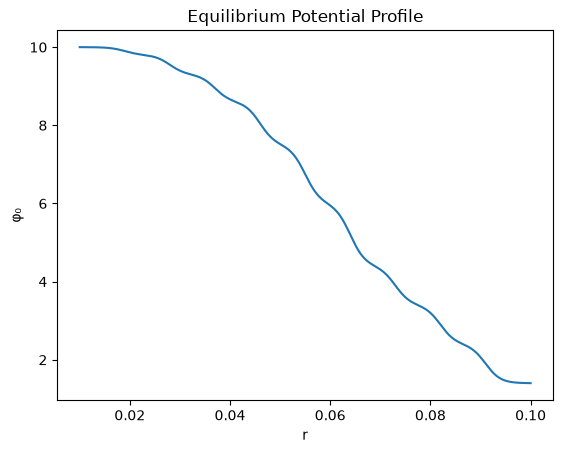

In [32]:
phi_0 = phi_0_func(r_values, [10, 9.8, 9.3, 8.6, 7.5, 6.0, 4.4, 3.4, 2.4, 1.4], epsilon=0.003)

plt.plot(r_values, phi_0)
plt.title("Equilibrium Potential Profile")
plt.xlabel("r")
plt.ylabel("φ₀")    

In [40]:
from scipy.interpolate import CubicSpline

def phi_0_func(r, values):
    r_ctrl = np.linspace(r[0], r[-1], len(values))
    return CubicSpline(r_ctrl, values)(r)

phi_0 = phi_0_func(r_values, [10, 9.8, 9.3, 8.6, 7.5, 6.0, 4.4, 3.4, 2.4, 1.4])

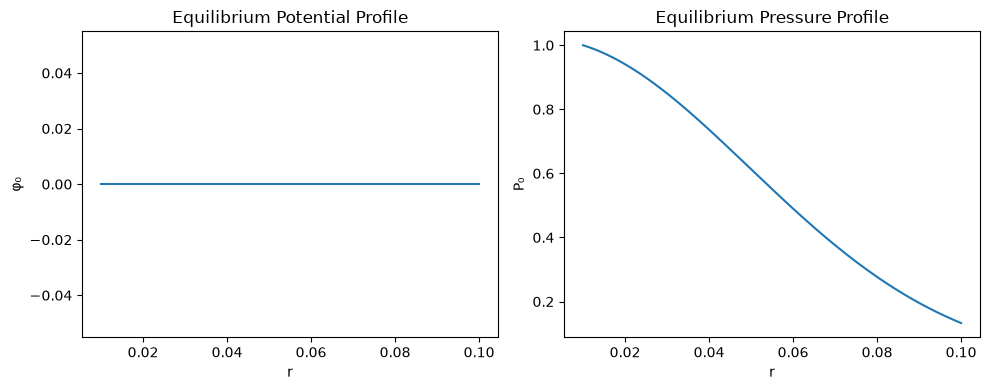

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(r_values, phi_0)
ax1.set_title("Equilibrium Potential Profile")
ax1.set_xlabel("r")
ax1.set_ylabel("φ₀")

ax2.plot(r_values, p_0)
ax2.set_title("Equilibrium Pressure Profile")
ax2.set_xlabel("r")
ax2.set_ylabel("P₀")

plt.tight_layout()
plt.show()

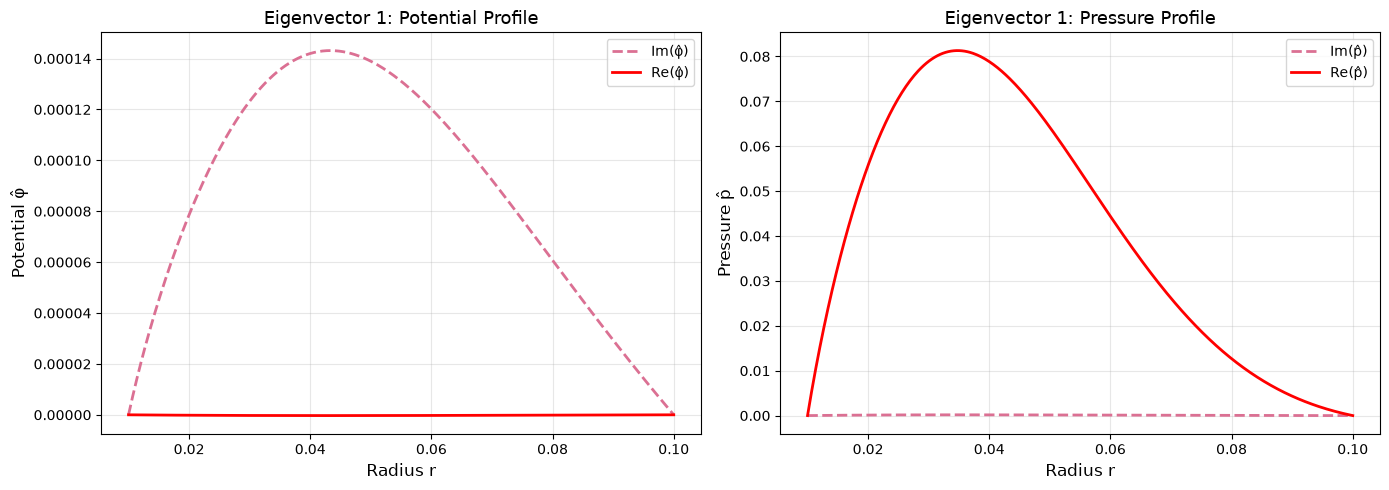

In [14]:
# Eigenvalue for null space vectors are inf, so we only look at the finite eigenvalues
finite_mask = np.isfinite(eigenvalues)
finite_evals = eigenvalues[finite_mask]
finite_indices = np.where(finite_mask)[0]
eigenvector_index = finite_indices[np.argmax(np.real(finite_evals))]

eigenvector = eigenvectors[:, eigenvector_index]
potential = eigenvector[:N]
pressure = eigenvector[N:2*N]

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot potential
ax1.plot(r_values, np.imag(potential), '--', linewidth=2, label='Im(φ̂)', color='palevioletred')
ax1.plot(r_values, np.real(potential), linewidth=2, label='Re(φ̂)', color='red')
ax1.set_xlabel('Radius r', fontsize=12)
ax1.set_ylabel('Potential φ̂', fontsize=12)
ax1.set_title(f'Eigenvector {eigenvector_index}: Potential Profile', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot pressure
ax2.plot(r_values, np.imag(pressure), '--', linewidth=2, label='Im(p̂)', color='palevioletred')
ax2.plot(r_values, np.real(pressure), linewidth=2, label='Re(p̂)', color='red')
ax2.set_xlabel('Radius r', fontsize=12)
ax2.set_ylabel('Pressure p̂', fontsize=12)
ax2.set_title(f'Eigenvector {eigenvector_index}: Pressure Profile', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

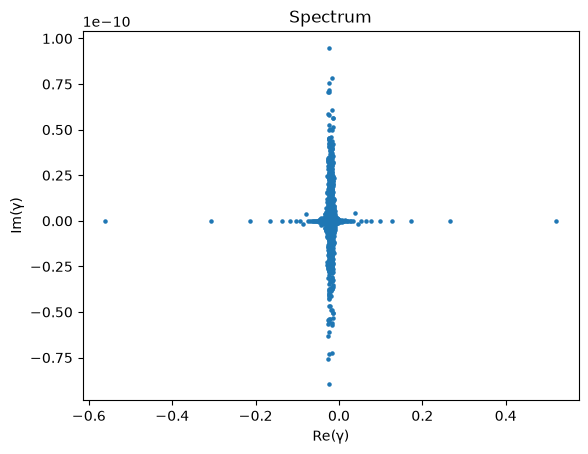

In [16]:
plt.scatter(np.real(finite_evals), np.imag(finite_evals), s=5)
plt.xlabel("Re(γ)"); plt.ylabel("Im(γ)")
plt.title("Spectrum")
plt.show()

In [15]:
print(np.max(np.real(finite_evals)))

0.5207943929961449


# Grid search

### Discrete

### Continouous

# Bayesian Optimization

### Discrete

Bayesian optimisation — minimising growth rate γ
  Electrodes     : 5
  Voltage bounds : [0.0, 10.0]
  Total evals    : 450  (random init: 75)
  [  1]  γ = 198.178260   voltages = [7.965 1.834 7.797 5.969 4.458]
  [  2]  γ = 24.104856   voltages = [1.    4.592 3.337 1.429 6.509]
  [  3]  γ = 164.129940   voltages = [5.640e-01 7.220e+00 9.386e+00 8.000e-03 9.922e+00]
  [  4]  γ = 89.185497   voltages = [6.175 6.117 0.071 0.231 5.248]
  [  5]  γ = 258.538090   voltages = [3.999 0.467 9.738 2.328 0.906]
  [  6]  γ = 171.386102   voltages = [6.184 3.825 9.832 4.668 8.599]
  [  7]  γ = 61.432595   voltages = [6.803 4.505 0.133 9.422 5.633]
  [  8]  γ = 68.593735   voltages = [3.854 0.16  2.309 2.41  6.833]
  [  9]  γ = 160.750139   voltages = [6.1   8.332 1.734 3.911 1.822]
  [ 10]  γ = 59.225176   voltages = [7.554 4.252 2.079 5.677 0.313]
  [ 11]  γ = 102.529392   voltages = [8.423 4.498 3.952 9.267 7.273]
  [ 12]  γ = 72.903082   voltages = [3.265 5.704 5.208 9.612 8.445]
  [ 13]  γ = 55

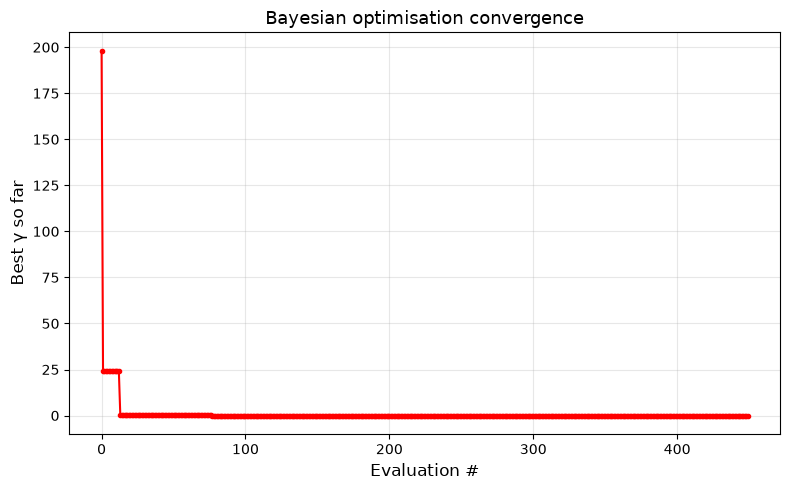

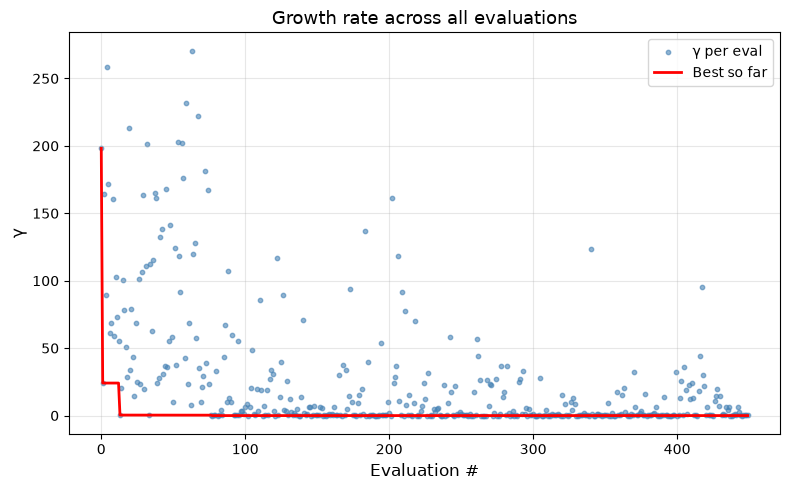

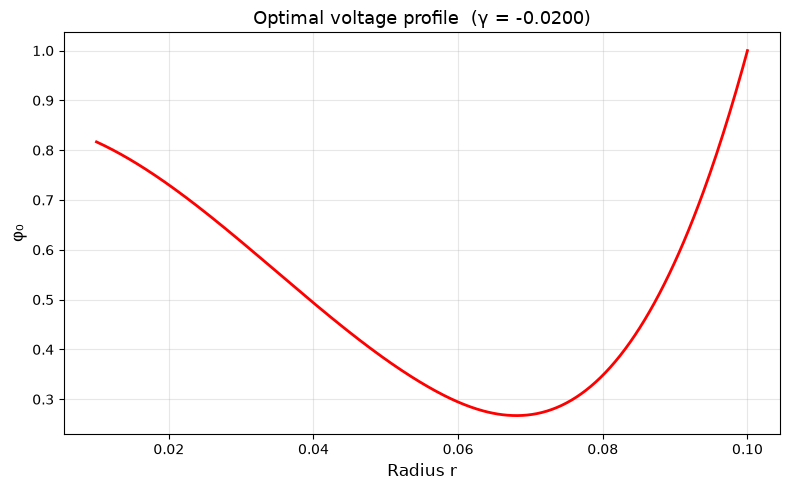

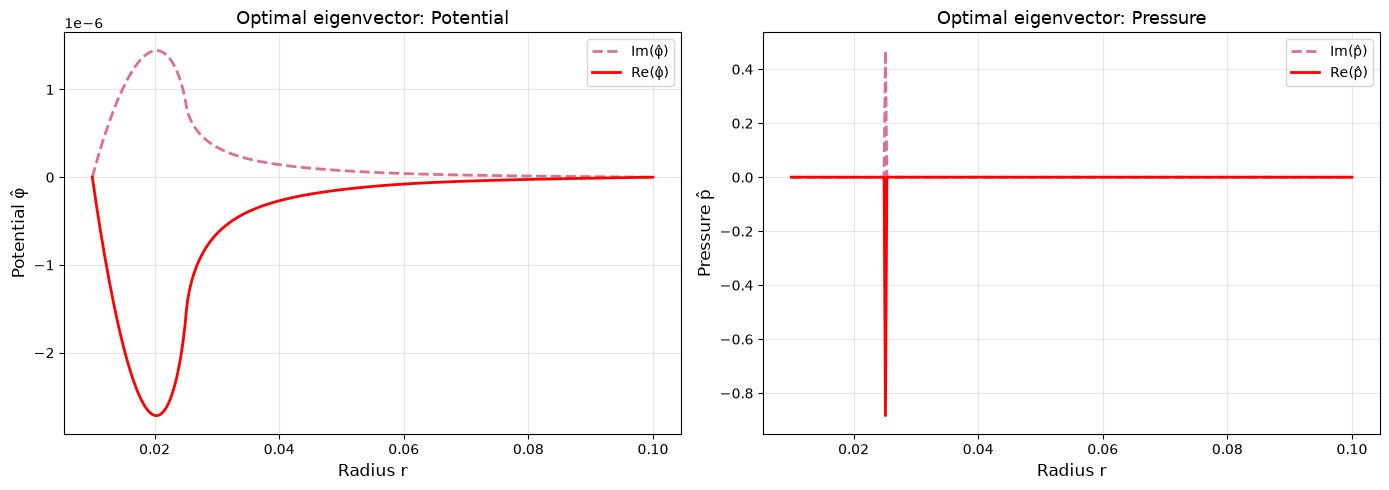


Plots saved to: plots/optimization/


In [5]:
import os

# ── Output directory ─────────────────────────────────────────────────────────
OUT_DIR = os.path.join("plots", "optimization")

# ── Bayesian optimisation ────────────────────────────────────────────────────
N_ELECTRODES   = 5
V_MIN, V_MAX   = 0.0, 10.0
N_CALLS        = 450
N_INITIAL      = 75

space = [Real(V_MIN, V_MAX, name=f'v{i}') for i in range(N_ELECTRODES)]

print("=" * 60)
print("Bayesian optimisation — minimising growth rate γ")
print(f"  Electrodes     : {N_ELECTRODES}")
print(f"  Voltage bounds : [{V_MIN}, {V_MAX}]")
print(f"  Total evals    : {N_CALLS}  (random init: {N_INITIAL})")
print("=" * 60)

result = gp_minimize(
    growth_rate,
    space,
    n_calls=N_CALLS,
    n_initial_points=N_INITIAL,
    acq_func='EI',
    noise=1e-6,
    random_state=42,
    verbose=False,
)

# ── Results ──────────────────────────────────────────────────────────────────
best_voltages = np.array(result.x)
best_gamma    = result.fun

print("\n" + "=" * 60)
print("OPTIMISATION COMPLETE")
print(f"  Minimum γ        : {best_gamma:.6f}")
print(f"  Optimal voltages : {np.round(best_voltages, 4)}")
print("=" * 60)

# ── Plot 1: convergence history ───────────────────────────────────────────────
fig = plt.figure(figsize=(8, 5))
plt.plot(np.minimum.accumulate(result.func_vals), 'o-', markersize=3, color='red')
plt.xlabel("Evaluation #", fontsize=12)
plt.ylabel("Best γ so far", fontsize=12)
plt.title("Bayesian optimisation convergence", fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "convergence.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# ── Plot 2: all evaluations ───────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 5))
plt.scatter(range(len(result.func_vals)), result.func_vals, s=10, alpha=0.6, color='steelblue', label='γ per eval')
plt.plot(np.minimum.accumulate(result.func_vals), color='red', linewidth=2, label='Best so far')
plt.xlabel("Evaluation #", fontsize=12)
plt.ylabel("γ", fontsize=12)
plt.title("Growth rate across all evaluations", fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "all_evaluations.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# ── Plot 3: optimal phi_0 profile ────────────────────────────────────────────
phi_0_opt = phi_0_func(r_values, best_voltages)

fig = plt.figure(figsize=(8, 5))
plt.plot(r_values, phi_0_opt, color='red', linewidth=2)
plt.xlabel("Radius r", fontsize=12)
plt.ylabel("φ₀", fontsize=12)
plt.title(f"Optimal voltage profile  (γ = {best_gamma:.4f})", fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "optimal_phi0.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# ── Plot 4: optimal eigenvector ───────────────────────────────────────────────
A_opt, B_opt = create_A_and_B(N, dr, m, r_values, phi_0_opt, p_0, v_parallel, H, k, U)
evals_opt, evecs_opt = eig(B_opt, A_opt)
finite_mask  = np.isfinite(evals_opt)
finite_evals = evals_opt[finite_mask]
finite_idx   = np.where(finite_mask)[0]
evec_idx     = finite_idx[np.argmax(np.real(finite_evals))]
evec         = evecs_opt[:, evec_idx]
potential    = evec[:N]
pressure     = evec[N:2*N]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(r_values, np.imag(potential), '--', linewidth=2, label='Im(φ̂)', color='palevioletred')
ax1.plot(r_values, np.real(potential),        linewidth=2, label='Re(φ̂)', color='red')
ax1.set_xlabel('Radius r', fontsize=12); ax1.set_ylabel('Potential φ̂', fontsize=12)
ax1.set_title('Optimal eigenvector: Potential', fontsize=13)
ax1.grid(True, alpha=0.3); ax1.legend()

ax2.plot(r_values, np.imag(pressure), '--', linewidth=2, label='Im(p̂)', color='palevioletred')
ax2.plot(r_values, np.real(pressure),        linewidth=2, label='Re(p̂)', color='red')
ax2.set_xlabel('Radius r', fontsize=12); ax2.set_ylabel('Pressure p̂', fontsize=12)
ax2.set_title('Optimal eigenvector: Pressure', fontsize=13)
ax2.grid(True, alpha=0.3); ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "optimal_eigenvector.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nPlots saved to: {OUT_DIR}/")


### Continuous